In [3]:
#!/usr/bin/env python
# coding: utf-8
"""
ImplicitPNASolver Validation Code v2
─────────────────────────────────────
Synod design deliberation v2 결과 반영 (2026-03-13):
  - 전체 CGDN v3 코드 그대로 사용 (FiLMGenerator, CGDNBlock, CGDN — 간소화 없음)
  - 3가지 MP 정확도 검증:
    1. Forward  : bisection으로 찾은 y_pna 기반 Mp vs 해석적 Mp (직접 계산)
    2. Backward : IFT gradient vs 해석적 gradient vs Finite Difference (3-way 비교)
                  해석적 해: dMp/dy_i = t_i·fy_i·sign(y_i - y_pna)
                  (간접항은 평형 조건에서 0이므로 직접항만)
    3. Epoch별  : pred_mp vs target_mp 수렴 정확도
  - 구조: 1 section, 3 parts (Outer/Reinf/Inner), 30 nodes

핵심 수식:
  Forward   : Mp = Σ t_i·fy_i·|y_i - y_pna|  (bisection으로 y_pna 결정)
  Analytic ∇: dMp/dy_i = t_i·fy_i·sign(y_i - y_pna)  [평형조건에서 간접항=0]
  IFT ∇     : direct + indirect  (indirect ≈ 0 검증 포함)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows의 경우
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
import math
from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


# ══════════════════════════════════════════════════════════════════
# ImplicitPNASolver + CGDN  (20260312_v3.py 그대로 — 수정 없음)
# ══════════════════════════════════════════════════════════════════

class ImplicitPNASolver(torch.autograd.Function):
    """
    미분 가능한 소성 중립축(PNA) 및 전소성 모멘트(Mp) 계산기
    Forward : Bisection으로 인장력=압축력 평형점(y_pna) 탐색
    Backward: IFT로 ∂y_pna/∂coords 계산 → chain-rule로 ∂Mp/∂coords 전파
    """

    @staticmethod
    def forward(ctx, coords, t, fy, edge_index, n_iter=30):
        with torch.no_grad():
            y = coords[:, 1]
            t_flat = t.squeeze(-1)
            fy_flat = fy.squeeze(-1)

            y_lo = y.min().clone()
            y_hi = y.max().clone()

            for _ in range(n_iter):
                y_mid = 0.5 * (y_lo + y_hi)
                F_tens = torch.sum(t_flat * fy_flat * (y > y_mid).float())
                F_comp = torch.sum(t_flat * fy_flat * (y < y_mid).float())
                if F_tens > F_comp:
                    y_lo = y_mid
                else:
                    y_hi = y_mid

            y_pna = 0.5 * (y_lo + y_hi)

        d = torch.abs(coords[:, 1] - y_pna)
        area = t_flat
        mp_pred = torch.sum(area * fy_flat * d)

        ctx.save_for_backward(coords, t, fy, y_pna.unsqueeze(0), edge_index)
        return mp_pred

    @staticmethod
    def backward(ctx, grad_output):
        coords, t, fy, y_pna_buf, edge_index = ctx.saved_tensors
        y_pna = y_pna_buf.squeeze(0)

        y = coords[:, 1]
        t_flat = t.squeeze(-1)
        fy_flat = fy.squeeze(-1)
        s = torch.sign(y - y_pna)

        dg_dy_pna = -torch.sum(t_flat * fy_flat)
        dg_dy = t_flat * fy_flat
        dy_pna_dy = -dg_dy / (dg_dy_pna + 1e-12)

        direct   = t_flat * fy_flat * s          # 직접항
        indirect = -torch.sum(t_flat * fy_flat * s) * dy_pna_dy  # 간접항 (평형에서 ≈0)
        dMp_dy   = direct + indirect

        grad_coords = torch.zeros_like(coords)
        grad_coords[:, 1] = grad_output * dMp_dy

        return grad_coords, None, None, None, None


def calculate_mpl(coords, t, fy, edge_index):
    return ImplicitPNASolver.apply(coords, t, fy, edge_index)


class FiLMGenerator(nn.Module):
    """target_mp [B, 1] → (gamma, beta) [B, hidden]"""
    MP_SCALE = 1e6

    def __init__(self, hidden_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, hidden_channels * 2),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, target_mp):
        target_mp_norm = target_mp / self.MP_SCALE
        out = self.net(target_mp_norm)
        delta_gamma, beta = torch.chunk(out, 2, dim=-1)
        gamma = 1.0 + delta_gamma
        return gamma, beta


class CGDNBlock(nn.Module):
    """GATv2Conv → LayerNorm → FiLM modulation → GELU → Residual  (AdaIN pattern)"""
    def __init__(self, hidden_channels: int, heads: int = 4, edge_dim: int = 4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads,
            edge_dim=edge_dim,
            concat=True,
        )
        self.norm = LayerNorm(hidden_channels)

    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)
        h = self.norm(h)
        h = gamma * h + beta
        h = F.gelu(h)
        h = h + h_res
        return h


class CGDN(nn.Module):
    """
    Constraint-aware Graph Deformation Network (v3)
    입력 노드 특징 (in_channels=8): [x, y, fix_x, fix_y, part_id, section_id, t, fy]
    엣지 특징 (edge_dim=4): [길이, 각도, part_id, edge_type]
    """

    def __init__(
        self,
        in_channels: int = 8,
        hidden_channels: int = 128,
        num_layers: int = 4,
        heads: int = 4,
        edge_dim: int = 4,
        max_displacement: float = 50.0,
    ):
        super().__init__()
        self.max_displacement = max_displacement
        self.num_layers = num_layers

        self.node_encoder = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            LayerNorm(hidden_channels),
            nn.GELU(),
        )
        self.film_generators = nn.ModuleList([
            FiLMGenerator(hidden_channels) for _ in range(num_layers)
        ])
        self.blocks = nn.ModuleList([
            CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim)
            for _ in range(num_layers)
        ])
        self.decoder = nn.Sequential(
            nn.Linear(hidden_channels, 64),
            nn.GELU(),
            nn.Linear(64, 2),
        )

    def forward(self, x, edge_index, edge_attr, target_mp,
                fix_x_mask, fix_y_mask, join_pairs=None):
        h = self.node_encoder(x)

        for i, block in enumerate(self.blocks):
            gamma, beta = self.film_generators[i](target_mp)
            h = block(h, edge_index, edge_attr, gamma, beta)

        delta_coords = self.decoder(h)
        delta_coords = torch.clamp(delta_coords, -self.max_displacement, self.max_displacement)

        delta_x = delta_coords[:, 0:1] * (~fix_x_mask).float()
        delta_y = delta_coords[:, 1:2] * (~fix_y_mask).float()
        delta_coords = torch.cat([delta_x, delta_y], dim=1)

        new_coords = x[:, :2] + delta_coords

        if join_pairs is not None and join_pairs.shape[0] > 0:
            u_idx = join_pairs[:, 0]
            v_idx = join_pairs[:, 1]
            mid = (new_coords[u_idx] + new_coords[v_idx]) * 0.5
            new_coords = new_coords.clone()
            new_coords[u_idx] = mid
            new_coords[v_idx] = mid

        return new_coords, delta_coords

ImplicitPNASolver 알고리즘 정확도 검증
구조: 1 section, 3 parts (Outer/Reinf/Inner), 30 nodes
모델: CGDN v3 (hidden=128, layers=4, heads=4) — 전체 코드 그대로

데이터: nodes=torch.Size([30, 8]) | edges=torch.Size([2, 54])

[ Section 2-A ] Forward 정확성 검증 (bisection Mp vs 해석적 Mp)
  y_pna (bisection)     :    40.000000 mm
  Equilibrium residual  : 4.500000e+03  -> WARN
  Solver Mp             :     729,000.0000 N·mm
  Analytic Mp           :     729,000.0000 N·mm
  Absolute Error        :         0.000000 N·mm
  Relative Error        :     0.000000%  -> PASS

[ Section 2-B ] Backward 정확도 (IFT vs 해석적 vs Finite Diff)

  ── 간접항(Indirect Term) 크기 검증 ──
  sum(t·fy·s) [평형 잔차]  : -2.550000e+04  -> LARGE
  max |indirect term|      : 1.085106e+03
  mean |indirect term|     : 8.500000e+02

   Node |      Autograd |      Analytic |    FiniteDiff | Err(A-An)% | Err(A-FD)%
  ------+---------------+---------------+---------------+------------+-----------
     12 |    -1914.8936 |    -3000.0000 |       -0.0042 |   36.1702% WA

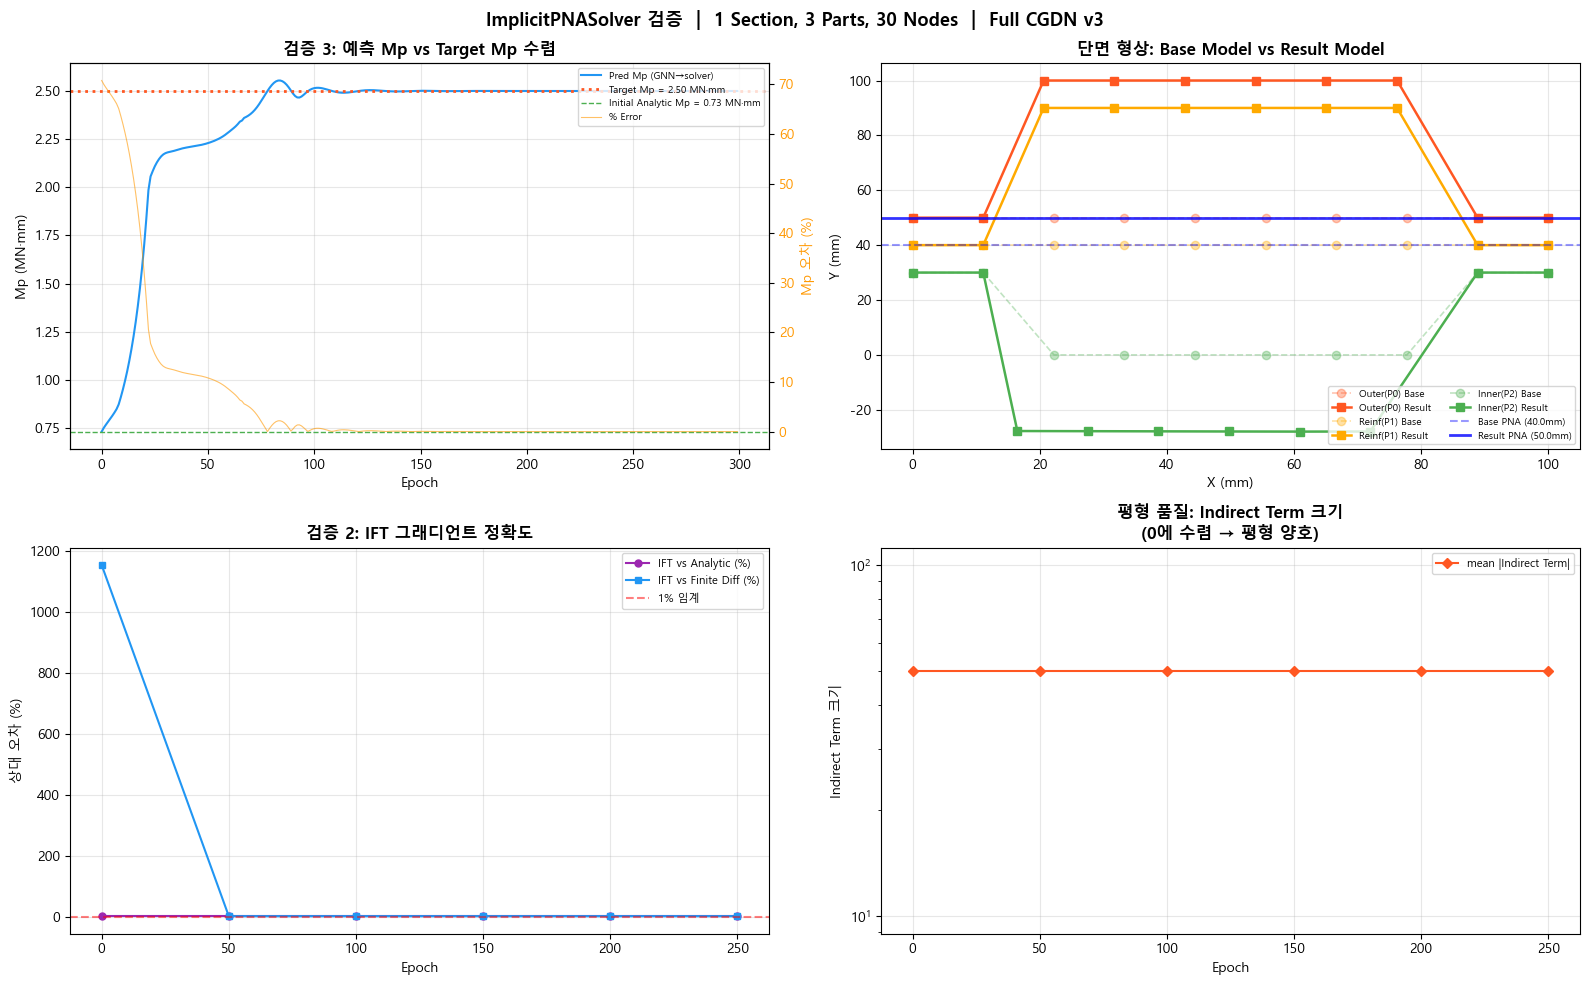


결과 저장: docs/validate_pna_result.png

최종 결과 요약
  Initial Mp (analytic) :     729,000.00 N·mm
  Initial y_pna         :      40.000000 mm
  Final pred_mp         :      2,500,000 N·mm
  Target Mp             :      2,500,000 N·mm
  Final Error           :   0.00%
  Final grad_err (an)   :  2.128%
  Final grad_err (fd)   :  2.128%
  Final indirect_mag    : 5.0000e+01


In [ ]:
# ══════════════════════════════════════════════════════════════════
# SECTION 1: Data Setup  (1 section, 3 parts, 30 nodes)
# ══════════════════════════════════════════════════════════════════

def build_simple_section():
    """
    1 section (section_id=0), 3 parts:
      Part 0 (Outer): y=50, t=1.5, fy=1500
      Part 1 (Reinf): y=40, t=2.0, fy=1500
      Part 2 (Inner): y=20, t=1.5, fy=1200
    Fixed nodes i=0,1,8,9 → fix_x=fix_y=1
    Node features: [x, y, fix_x, fix_y, part_id, section_id, t, fy]
    """
    part_configs = [
        (0, 50.0, 1.5, 1500.0),
        (1, 40.0, 2.0, 1500.0),
        (2, 20.0, 1.5, 1200.0),
    ]
    nodes = []
    node_registry = {}
    idx = 0
    for part_id, y_coord, t_val, fy_val in part_configs:
        for i in range(10):
            x_coord = i * (100.0 / 9.0)
            fix = 1.0 if i in [0, 1, 8, 9] else 0.0
            
            # part 2의 경우: fix된 노드는 y=0, 나머지는 y=0
            if part_id == 2:
                y_coord_node = 30.0 if fix == 1.0 else 0.0
            else:
                y_coord_node = y_coord
            
            nodes.append([x_coord, y_coord_node, fix, fix, float(part_id), 0.0, t_val, fy_val])
            node_registry[(part_id, i)] = idx
            idx += 1

    x = torch.tensor(nodes, dtype=torch.float32)

    src_list, dst_list, edge_attr_list = [], [], []

    def add_edge(u, v, part_id):
        dx = x[v, 0] - x[u, 0]
        dy = x[v, 1] - x[u, 1]
        length = math.sqrt(dx**2 + dy**2)
        angle  = math.atan2(dy, dx)
        src_list.extend([u, v])
        dst_list.extend([v, u])
        edge_attr_list.extend([[length, angle, float(part_id), 0.0],
                                [length, -angle, float(part_id), 0.0]])

    for part_id, _, _, _ in part_configs:
        for i in range(9):
            u = node_registry[(part_id, i)]
            v = node_registry[(part_id, i + 1)]
            add_edge(u, v, part_id)

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_attr  = torch.tensor(edge_attr_list, dtype=torch.float32)
    join_pairs = torch.zeros((0, 2), dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                join_pairs=join_pairs), node_registry


# ══════════════════════════════════════════════════════════════════
# 보조 함수: 해석적 y_pna 계산 (검증용)
# ══════════════════════════════════════════════════════════════════

def compute_y_pna_ref(coords, t, fy, n_iter=50):
    """bisection으로 y_pna 계산 (ImplicitPNASolver.forward 와 동일 로직)"""
    with torch.no_grad():
        y = coords[:, 1] if coords.dim() == 2 else coords
        t_flat  = t.squeeze(-1)
        fy_flat = fy.squeeze(-1)
        y_lo = y.min().clone()
        y_hi = y.max().clone()
        for _ in range(n_iter):
            y_mid  = 0.5 * (y_lo + y_hi)
            F_tens = torch.sum(t_flat * fy_flat * (y > y_mid).float())
            F_comp = torch.sum(t_flat * fy_flat * (y < y_mid).float())
            if F_tens > F_comp:
                y_lo = y_mid
            else:
                y_hi = y_mid
        return 0.5 * (y_lo + y_hi)


# ══════════════════════════════════════════════════════════════════
# SECTION 2-A: Forward 정확성 검증
# ══════════════════════════════════════════════════════════════════

def validate_forward(data):
    """
    검증 1: Forward process의 Mp 정확도
    - solver Mp (ImplicitPNASolver) vs 해석적 Mp (bisection y_pna로 직접 계산)
    - 평형 조건 검증: sum(t·fy·sign(y - y_pna)) ≈ 0
    """
    print("\n" + "=" * 65)
    print("[ Section 2-A ] Forward 정확성 검증 (bisection Mp vs 해석적 Mp)")
    print("=" * 65)

    coords = data.x[:, :2].clone()
    t  = data.x[:, 6:7].clone()
    fy = data.x[:, 7:8].clone()

    # ImplicitPNASolver 출력
    mp_solver = calculate_mpl(coords, t, fy, None)

    # 해석적 계산 (독립 bisection으로 y_pna 획득)
    with torch.no_grad():
        y_pna_ref = compute_y_pna_ref(coords, t, fy)
        y_flat    = coords[:, 1]
        t_flat    = t.squeeze(-1)
        fy_flat   = fy.squeeze(-1)

        mp_analytic = torch.sum(t_flat * fy_flat * torch.abs(y_flat - y_pna_ref))

        # 평형 조건 검증: sum(t·fy·sign(y - y_pna)) = 0 이어야 함
        s_ref = torch.sign(y_flat - y_pna_ref)
        equil_residual = torch.sum(t_flat * fy_flat * s_ref)

    err_mp  = abs(mp_solver.item() - mp_analytic.item())
    err_pct = err_mp / (mp_analytic.item() + 1e-10) * 100

    print(f"  y_pna (bisection)     : {y_pna_ref.item():>12.6f} mm")
    print(f"  Equilibrium residual  : {equil_residual.item():>12.6e}  -> {'OK' if abs(equil_residual.item()) < 1.0 else 'WARN'}")
    print(f"  Solver Mp             : {mp_solver.item():>16,.4f} N·mm")
    print(f"  Analytic Mp           : {mp_analytic.item():>16,.4f} N·mm")
    print(f"  Absolute Error        : {err_mp:>16.6f} N·mm")
    print(f"  Relative Error        : {err_pct:>12.6f}%  -> {'PASS' if err_pct < 0.001 else 'FAIL'}")
    return mp_solver.item(), mp_analytic.item(), y_pna_ref.item()


# ══════════════════════════════════════════════════════════════════
# SECTION 2-B: Backward 그래디언트 정확도 검증 (3-way)
# ══════════════════════════════════════════════════════════════════

def validate_backward(data, n_check=8, eps=1e-2):
    """
    검증 2: Backward process의 IFT 그래디언트 정확도
    3-way 비교:
      (A) g_autograd : ImplicitPNASolver.backward (IFT, 직접항+간접항)
      (B) g_analytic : t_i·fy_i·sign(y_i - y_pna)  (해석적, 직접항만; 간접항=0 at 평형)
      (C) g_fd       : 중앙 유한차분
    추가: 간접항(indirect term) 크기 검증 (평형에서 ≈ 0이어야 함)
    """
    print("\n" + "=" * 65)
    print("[ Section 2-B ] Backward 정확도 (IFT vs 해석적 vs Finite Diff)")
    print("=" * 65)

    # float64 사용으로 수치 정밀도 향상
    coords = data.x[:, :2].clone().double()
    t      = data.x[:, 6:7].clone().double()
    fy     = data.x[:, 7:8].clone().double()
    fix_y  = data.x[:, 3].bool()
    free_indices = (~fix_y).nonzero(as_tuple=True)[0]

    # y_pna 참조값 (float64)
    y_pna_ref = compute_y_pna_ref(coords, t, fy)

    # (A) Autograd (IFT backward)
    coords_ag = coords.clone().requires_grad_(True)
    mp = calculate_mpl(coords_ag, t, fy, None)
    mp.backward()
    g_autograd = coords_ag.grad[:, 1].detach()

    # (B) 해석적 그래디언트: t_i·fy_i·sign(y_i - y_pna)
    with torch.no_grad():
        y_flat    = coords[:, 1]
        t_flat    = t.squeeze(-1)
        fy_flat   = fy.squeeze(-1)
        s_ref     = torch.sign(y_flat - y_pna_ref)
        g_analytic = t_flat * fy_flat * s_ref  # 직접항 (해석해)

        # 간접항 크기 계산 (= sum(t·fy·s) * dy_pna/dy_i, 평형에서 ≈ 0)
        sum_tfy_s   = torch.sum(t_flat * fy_flat * s_ref)
        sum_tfy     = torch.sum(t_flat * fy_flat)
        dy_pna_dy   = (t_flat * fy_flat) / (sum_tfy + 1e-12)
        indirect    = -sum_tfy_s * dy_pna_dy

    print(f"\n  ── 간접항(Indirect Term) 크기 검증 ──")
    print(f"  sum(t·fy·s) [평형 잔차]  : {sum_tfy_s.item():>12.6e}  -> {'OK (≈0)' if abs(sum_tfy_s.item()) < 10 else 'LARGE'}")
    print(f"  max |indirect term|      : {torch.max(torch.abs(indirect)).item():>12.6e}")
    print(f"  mean |indirect term|     : {torch.mean(torch.abs(indirect)).item():>12.6e}")

    # 노드별 비교 (선택된 free 노드)
    perm   = torch.randperm(len(free_indices))[:n_check]
    chosen = free_indices[perm]

    errors_ag_analytic = []
    errors_ag_fd       = []

    print(f"\n  {'Node':>5} | {'Autograd':>13} | {'Analytic':>13} | {'FiniteDiff':>13} | {'Err(A-An)%':>10} | {'Err(A-FD)%':>10}")
    print(f"  {'-'*5}-+-{'-'*13}-+-{'-'*13}-+-{'-'*13}-+-{'-'*10}-+-{'-'*10}")

    for idx in chosen:
        idx = idx.item()

        # (C) Finite Difference
        c_p = coords.clone(); c_p[idx, 1] += eps
        c_m = coords.clone(); c_m[idx, 1] -= eps
        with torch.no_grad():
            mp_p = calculate_mpl(c_p, t, fy, None).item()
            mp_m = calculate_mpl(c_m, t, fy, None).item()
        fd_g = (mp_p - mp_m) / (2 * eps)

        ag_g = g_autograd[idx].item()
        an_g = g_analytic[idx].item()

        err_an = abs(ag_g - an_g) / (abs(an_g) + 1e-10) * 100
        err_fd = abs(ag_g - fd_g) / (abs(fd_g) + 1e-10) * 100
        errors_ag_analytic.append(err_an)
        errors_ag_fd.append(err_fd)

        s_an = "OK" if err_an < 1.0 else "WARN"
        s_fd = "OK" if err_fd < 2.0 else "WARN"
        print(f"  {idx:>5} | {ag_g:>13.4f} | {an_g:>13.4f} | {fd_g:>13.4f} | {err_an:>9.4f}% {s_an} | {err_fd:>9.4f}% {s_fd}")

    mean_an = np.mean(errors_ag_analytic)
    mean_fd = np.mean(errors_ag_fd)
    print(f"\n  평균 오차 (Autograd vs Analytic) : {mean_an:.4f}%")
    print(f"  평균 오차 (Autograd vs FiniteDiff): {mean_fd:.4f}%")
    print(f"  종합 판정: {'PASS' if mean_an < 1.0 and mean_fd < 2.0 else 'FAIL'}")
    return errors_ag_analytic, errors_ag_fd


# ══════════════════════════════════════════════════════════════════
# SECTION 2-C: Training Loop (전체 CGDN, epoch별 Mp 정확도)
# ══════════════════════════════════════════════════════════════════

def run_training(data, target_mp_val=2_500_000, max_epochs=300, lr=1e-3,
                 grad_check_interval=50):
    """
    검증 3: CGDN 학습 중 epoch별 Mp 수렴 정확도
    전체 CGDN (hidden=128, num_layers=4, heads=4) 사용.

    매 epoch 기록:
      - pred_mp   : GNN 변형 → ImplicitPNASolver → Mp (gradient 포함)
      - target_mp : 고정 설계 목표
    grad_check_interval 마다 추가 기록:
      - g_autograd vs g_analytic vs g_fd 오차
      - indirect term 크기 (평형 품질 지표)
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data   = data.to(device)

    model = CGDN(
        in_channels=8,
        hidden_channels=128,
        num_layers=4,
        heads=4,
        edge_dim=4,
        max_displacement=50.0,
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    x          = data.x
    edge_index = data.edge_index
    edge_attr  = data.edge_attr
    join_pairs = data.join_pairs if hasattr(data, 'join_pairs') else None
    base_coords = x[:, :2].detach().cpu()

    fix_x_mask = x[:, 2].bool().unsqueeze(1)
    fix_y_mask = x[:, 3].bool().unsqueeze(1)
    t  = x[:, 6:7]
    fy = x[:, 7:8]

    target_mp_node = torch.full((x.shape[0], 1), float(target_mp_val),
                                dtype=torch.float32, device=device)

    history = {
        'pred_mp':        [],
        'target_mp':      [],
        'mp_err_pct':     [],
        'grad_err_an':    [],
        'grad_err_fd':    [],
        'indirect_mag':   [],
        'grad_epochs':    [],
    }

    print(f"\n{'=' * 65}")
    print(f"[ Section 2-C ] Training  |  Target Mp = {target_mp_val:,.0f} N·mm  |  Epochs: {max_epochs}")
    print(f"  CGDN: hidden=128, layers=4, heads=4  (full v3, unchanged)")
    print(f"{'=' * 65}")

    new_coords = None
    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        new_coords, delta = model(
            x, edge_index, edge_attr, target_mp_node,
            fix_x_mask, fix_y_mask, join_pairs
        )
        pred_mp = calculate_mpl(new_coords, t, fy, None)

        loss = ((pred_mp - target_mp_val) / target_mp_val) ** 2
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        mp_err = abs(pred_mp.item() - target_mp_val) / target_mp_val * 100
        history['pred_mp'].append(pred_mp.item())
        history['target_mp'].append(target_mp_val)
        history['mp_err_pct'].append(mp_err)

        # 그래디언트 정확도 + 간접항 크기 (선택된 epoch)
        if epoch % grad_check_interval == 0:
            model.eval()
            with torch.enable_grad():
                nc_ag = new_coords.detach().clone().requires_grad_(True)
                mp2   = calculate_mpl(nc_ag, t, fy, None)
                mp2.backward()
                g_ag  = nc_ag.grad[:, 1].detach()

            # 해석적 그래디언트 + 간접항
            with torch.no_grad():
                y_pna_e   = compute_y_pna_ref(new_coords.detach(), t, fy)
                y_e       = new_coords.detach()[:, 1]
                t_flat_e  = t.squeeze(-1)
                fy_flat_e = fy.squeeze(-1)
                s_e       = torch.sign(y_e - y_pna_e)
                g_an      = t_flat_e * fy_flat_e * s_e
                sum_s_e   = torch.sum(t_flat_e * fy_flat_e * s_e)
                sum_tfy_e = torch.sum(t_flat_e * fy_flat_e)
                dy_pna_e  = (t_flat_e * fy_flat_e) / (sum_tfy_e + 1e-12)
                indirect_e = -sum_s_e * dy_pna_e
                indirect_mag = torch.mean(torch.abs(indirect_e)).item()

            # FD (대표 노드 1개)
            free_idx_e = (~fix_y_mask.squeeze()).nonzero(as_tuple=True)[0]
            pick = free_idx_e[len(free_idx_e) // 2].item()
            eps_fd = 1e-2
            c_p = new_coords.detach().clone(); c_p[pick, 1] += eps_fd
            c_m = new_coords.detach().clone(); c_m[pick, 1] -= eps_fd
            fd_g = (calculate_mpl(c_p, t, fy, None).item() -
                    calculate_mpl(c_m, t, fy, None).item()) / (2 * eps_fd)

            err_an = abs(g_ag[pick].item() - g_an[pick].item()) / (abs(g_an[pick].item()) + 1e-10) * 100
            err_fd = abs(g_ag[pick].item() - fd_g) / (abs(fd_g) + 1e-10) * 100

            history['grad_err_an'].append(err_an)
            history['grad_err_fd'].append(err_fd)
            history['indirect_mag'].append(indirect_mag)
            history['grad_epochs'].append(epoch)

            print(f"  Epoch {epoch:4d} | pred_mp: {pred_mp.item():>12,.0f} | "
                  f"target: {target_mp_val:>12,.0f} | err: {mp_err:>6.2f}% | "
                  f"grad_an: {err_an:.3f}% | grad_fd: {err_fd:.3f}% | "
                  f"indirect_mag: {indirect_mag:.4e}")

    final_new_coords = new_coords.detach().cpu() if new_coords is not None else base_coords
    return history, base_coords, final_new_coords

# ══════════════════════════════════════════════════════════════════
# SECTION 3: 시각화
# ══════════════════════════════════════════════════════════════════

def visualize_results(history, base_coords, result_coords, target_mp_val,
                      fwd_mp_analytic=None, y_pna_init=None, y_pna_final=None):
    """
    Panel 1: pred_mp vs target_mp 수렴 (epoch별, % error 2차 축)
    Panel 2: 단면 형상 Base Model vs Result Model (part별 색상) + PNA 위치 추가
    Panel 3: 그래디언트 정확도 (IFT vs Analytic vs FD, epoch별)
    Panel 4: 간접항(Indirect Term) 크기 (평형 품질, epoch별)
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    epochs = list(range(len(history['pred_mp'])))

    # ── Panel 1: Mp 수렴 ──
    ax  = axes[0]
    ax2 = ax.twinx()
    ax.plot(epochs, [v / 1e6 for v in history['pred_mp']],
            color='#2196F3', linewidth=1.5, label='Pred Mp (GNN→solver)')
    ax.axhline(target_mp_val / 1e6, color='#FF5722', linewidth=2.0, linestyle=':',
               label=f'Target Mp = {target_mp_val/1e6:.2f} MN·mm')
    if fwd_mp_analytic is not None:
        ax.axhline(fwd_mp_analytic / 1e6, color='#4CAF50', linewidth=1.0, linestyle='--',
                   label=f'Initial Analytic Mp = {fwd_mp_analytic/1e6:.2f} MN·mm')
    ax2.plot(epochs, history['mp_err_pct'],
             color='#FF9800', linewidth=0.8, alpha=0.6, linestyle='-', label='% Error')
    ax2.set_ylabel('Mp 오차 (%)', color='#FF9800')
    ax2.tick_params(axis='y', labelcolor='#FF9800')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mp (MN·mm)')
    ax.set_title('검증 1: 예측 Mp vs Target Mp 수렴', fontweight='bold')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.3)

    # ── Panel 2: 단면 형상 비교 ──
    ax = axes[1]
    base_np   = base_coords.numpy()
    result_np = result_coords.numpy()
    part_colors = {0: '#FF5722', 1: '#FFAA00', 2: '#4CAF50'}
    part_names  = {0: 'Outer(P0)', 1: 'Reinf(P1)', 2: 'Inner(P2)'}

    for part_id in range(3):
        s, e = part_id * 10, part_id * 10 + 10
        c = part_colors[part_id]
        name = part_names[part_id]
        ax.plot(base_np[s:e, 0], base_np[s:e, 1],
                'o--', color=c, alpha=0.35, linewidth=1.2, label=f'{name} Base')
        ax.plot(result_np[s:e, 0], result_np[s:e, 1],
                's-',  color=c, alpha=1.0,  linewidth=1.8, label=f'{name} Result')

    if y_pna_init is not None:
        ax.axhline(y_pna_init, color='blue', linestyle='--', alpha=0.4, linewidth=1.5, 
                   label=f'Base PNA ({y_pna_init:.1f}mm)')
    if y_pna_final is not None:
        ax.axhline(y_pna_final, color='blue', linestyle='-', alpha=0.8, linewidth=2.0, 
                   label=f'Result PNA ({y_pna_final:.1f}mm)')

    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title('단면 형상: Base Model vs Result Model', fontweight='bold')
    ax.legend(loc='best', fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

    # ── Panel 3: 그래디언트 정확도 ──
    ax = axes[2]
    if history['grad_epochs']:
        ge = history['grad_epochs']
        ax.plot(ge, history['grad_err_an'], 'o-', color='#9C27B0', linewidth=1.5,
                markersize=5, label='IFT vs Analytic (%)')
        ax.plot(ge, history['grad_err_fd'], 's-', color='#2196F3', linewidth=1.5,
                markersize=5, label='IFT vs Finite Diff (%)')
        ax.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='1% 임계')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('상대 오차 (%)')
        ax.set_title('검증 2: IFT 그래디언트 정확도', fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, 'No gradient check data',
                     ha='center', va='center', transform=axes[2].transAxes)

    # ── Panel 4: 간접항 크기 (평형 품질) ──
    ax = axes[3]
    if history['grad_epochs']:
        ax.plot(history['grad_epochs'], history['indirect_mag'],
                'D-', color='#FF5722', linewidth=1.5, markersize=5,
                label='mean |Indirect Term|')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Indirect Term 크기')
        ax.set_title('평형 품질: Indirect Term 크기\n(0에 수렴 → 평형 양호)', fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_yscale('log')
    else:
        axes[3].text(0.5, 0.5, 'No data', ha='center', va='center',
                     transform=axes[3].transAxes)

    plt.suptitle('ImplicitPNASolver 검증  |  1 Section, 3 Parts, 30 Nodes  |  Full CGDN v3',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()

    out_path = 'docs/validate_pna_result.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"\n결과 저장: {out_path}")


# ══════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    torch.manual_seed(42)
    np.random.seed(42)

    print("ImplicitPNASolver 알고리즘 정확도 검증")
    print("구조: 1 section, 3 parts (Outer/Reinf/Inner), 30 nodes")
    print("모델: CGDN v3 (hidden=128, layers=4, heads=4) — 전체 코드 그대로")

    # ── Section 1: Data Setup ──
    data, node_registry = build_simple_section()
    print(f"\n데이터: nodes={data.x.shape} | edges={data.edge_index.shape}")

    # ── Section 2-A: Forward 검증 ──
    mp_solver, mp_analytic, y_pna_init = validate_forward(data)

    # ── Section 2-B: Backward 검증 ──
    validate_backward(data, n_check=8, eps=1e-2)

# ── Section 2-C: Training + Epoch별 Mp 정확도 ──
    TARGET_MP = 2_500_000  # N·mm
    history, base_coords, result_coords = run_training(
        data,
        target_mp_val=TARGET_MP,
        max_epochs=300,
        lr=1e-3,
        grad_check_interval=50,
    )

    t_full = data.x[:, 6:7].cpu()
    fy_full = data.x[:, 7:8].cpu()
    result_coords_cpu = result_coords.cpu()
    
    y_pna_final = compute_y_pna_ref(result_coords_cpu, t_full, fy_full)

    # ── Section 3: Visualization ──
    visualize_results(history, base_coords.cpu(), result_coords_cpu, TARGET_MP,
                      fwd_mp_analytic=mp_analytic,
                      y_pna_init=y_pna_init,
                      y_pna_final=y_pna_final)

    # ── 최종 요약 ──
    final_pred = history['pred_mp'][-1]
    final_err  = abs(final_pred - TARGET_MP) / TARGET_MP * 100
    print(f"\n{'=' * 65}")
    print(f"최종 결과 요약")
    print(f"  Initial Mp (analytic) : {mp_analytic:>14,.2f} N·mm")
    print(f"  Initial y_pna         : {y_pna_init:>14.6f} mm")
    print(f"  Final pred_mp         : {final_pred:>14,.0f} N·mm")
    print(f"  Target Mp             : {TARGET_MP:>14,.0f} N·mm")
    print(f"  Final Error           : {final_err:>6.2f}%")
    if history['grad_epochs']:
        print(f"  Final grad_err (an)   : {history['grad_err_an'][-1]:>6.3f}%")
        print(f"  Final grad_err (fd)   : {history['grad_err_fd'][-1]:>6.3f}%")
        print(f"  Final indirect_mag    : {history['indirect_mag'][-1]:.4e}")
    print(f"{'=' * 65}")
